# Decision Tree

### Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import seaborn as sns

print("Libraries imported! ✅")

Libraries imported! ✅


In [9]:
# Cell 2 - Load Iris dataset
df = pd.read_csv(r"C:\Users\MINHAJ\Downloads\Data Set For Task-20260408T161732Z-3-001\Data Set For Task\1) iris.csv")

print("Shape:", df.shape)
print("\nSpecies to predict:", df['species'].unique())
df.head()

Shape: (150, 5)

Species to predict: ['setosa' 'versicolor' 'virginica']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
# Encode species (text → numbers)
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

# Separate features and target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Data ready! ✅")

Training samples: 120
Testing samples: 30
Data ready! ✅


In [11]:
# Train a full unpruned tree first
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

y_pred_full = dt_full.predict(X_test)

print("=== FULL TREE (No Pruning) ===")
print(f"Tree Depth:  {dt_full.get_depth()}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_full):.2%}")
print(f"F1 Score:    {f1_score(y_test, y_pred_full, average='weighted'):.2%}")

=== FULL TREE (No Pruning) ===
Tree Depth:  6
Accuracy:    100.00%
F1 Score:    100.00%


In [12]:
# Pruned tree — max_depth limits how deep the tree grows
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)

print("=== PRUNED TREE (max_depth=3) ===")
print(f"Tree Depth:  {dt_pruned.get_depth()}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_pruned):.2%}")
print(f"F1 Score:    {f1_score(y_test, y_pred_pruned, average='weighted'):.2%}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_pruned, 
      target_names=le.classes_))

=== PRUNED TREE (max_depth=3) ===
Tree Depth:  3
Accuracy:    100.00%
F1 Score:    100.00%

Full Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



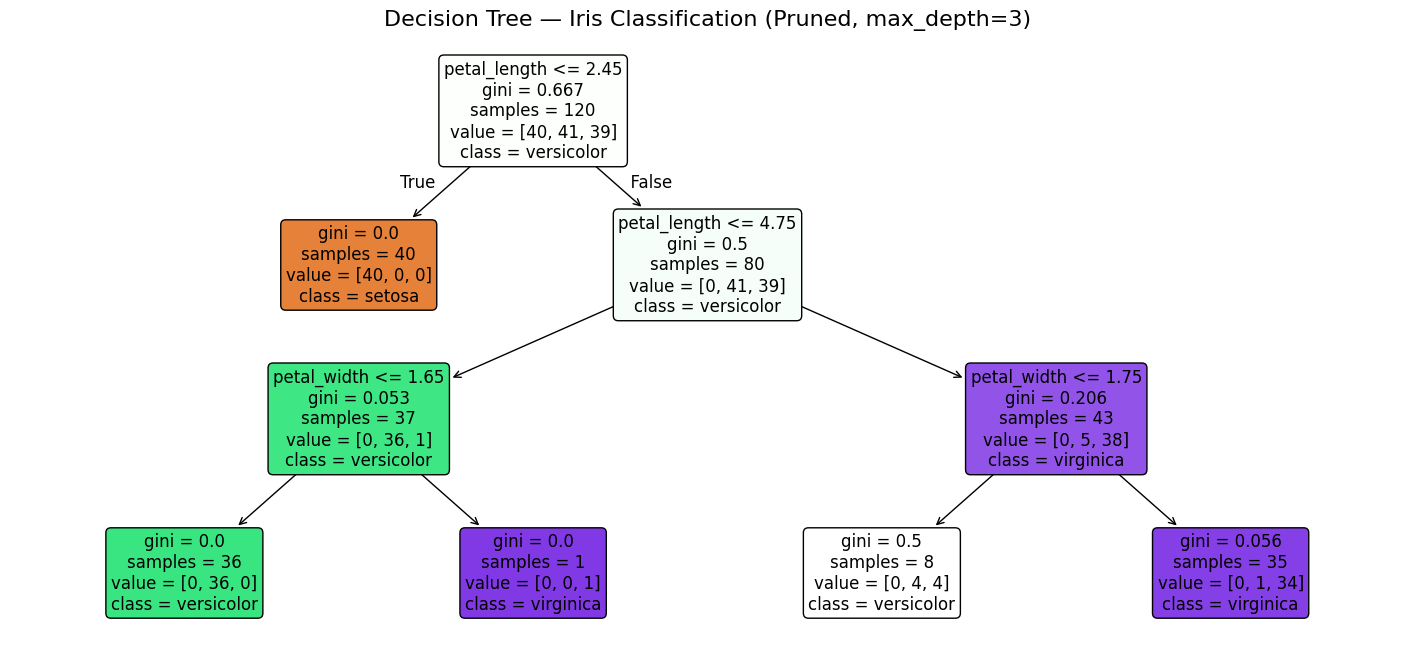

Tree visualized and saved! ✅


In [13]:
plt.figure(figsize=(18, 8))
plot_tree(dt_pruned, 
          feature_names=['sepal_length', 'sepal_width', 
                         'petal_length', 'petal_width'],
          class_names=le.classes_,
          filled=True,        # color the nodes
          rounded=True,       # rounded boxes
          fontsize=12)
plt.title("Decision Tree — Iris Classification (Pruned, max_depth=3)", 
          fontsize=16)
plt.savefig("decision_tree.png", bbox_inches='tight')
plt.show()
print("Tree visualized and saved! ✅")

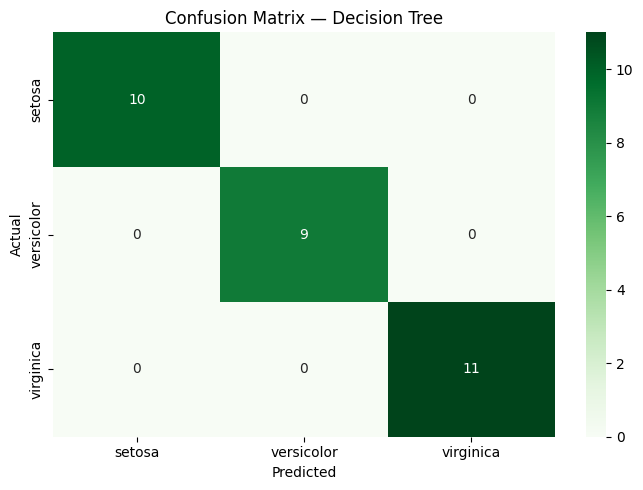


=== COMPARISON: Full vs Pruned ===
Full Tree   — Depth: 6, Accuracy: 100.00%
Pruned Tree — Depth: 3, Accuracy: 100.00%

Task 4 Complete! ✅


In [15]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_pruned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix — Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("dt_confusion_matrix.png")
plt.show()

print("\n=== COMPARISON: Full vs Pruned ===")
print(f"Full Tree   — Depth: {dt_full.get_depth()}, "
      f"Accuracy: {accuracy_score(y_test, y_pred_full):.2%}")
print(f"Pruned Tree — Depth: {dt_pruned.get_depth()}, "
      f"Accuracy: {accuracy_score(y_test, y_pred_pruned):.2%}")
print("\nTask 4 Complete! ✅")